# 01211373 : Machine Learning and Programming for Industry

## Lecture 2 Supplement 2 : Support vector machine and k-nearest neighbor  algorithms

From previous lectures, we learn how to classify with linear decision boundary (standard logistic regression), as well as linear prediction of continuous target (linear regression). Now we would want to extend to classifiers with nonlinear boundaries. 

In this lecture, we discuss 2 supervised ML algorithms that are popular and commonly used in academia as well as in industry. Instead of implementing from scratch, we now emphasize on using scikit-learn. Our focus is on classification, even though some algorithms are applicable to regression as well. 

### 4.1 Support Vector Machines (SVM)

From Wikipedia https://en.wikipedia.org/wiki/Support_vector_machine 

"In machine learning, support vector machines (SVMs, also support vector networks) are supervised max-margin models with associated learning algorithms that analyze data for classification and regression analysis.In addition to performing linear classification, SVMs can efficiently perform non-linear classification using the kernel trick, representing the data only through a set of pairwise similarity comparisons between the original data points using a kernel function, which transforms them into coordinates in a higher-dimensional feature space. Thus, SVMs use the kernel trick to implicitly map their inputs into high-dimensional feature spaces, where linear classification can be performed."

In SVMs, our optimization objective is to maximize the margin, defined as the distance between the separating hyperplnae (decision boundary) and the training examples closest to this hyperplane, called **support vectors.** This is illustrated in Figure 4.1 below.

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch03/figures/03_09.png" width=800 />

Figure 4.1 Decision boundary and support vectors (from Fig 3.10 of [1])



#### 4.1.1 Mathematical Interpretation

**Note :** This is some mathematical background of SVM captured from [Stanford CS229 course](https://www.youtube.com/playlist?list=PLoROMvodv4rMiGQp3WXShtMGgzqpfVfbU). Some details were omitted in the lecture but covered in [2]. The derivation is quite involved and may be skipped for those of you who are interested only on applying SVM to your ML problem.

**CS 229 videos for SVM** 
<ul>
<li /><a href="https://youtu.be/lDwow4aOrtg?si=tbEfJJ2rnVTg0b3C&t=2780">Lecture 6 :</a> Support Vector Machine
<li /><a href="https://youtu.be/8NYoQiRANpg?si=VqWkGhiwI4KGlOV4">Lecture 7 :</a> Kernels
</ul>

SVM can be thought of as a combination of  optimal margin classifier with so-called "kernel trick." For simplicity, we consider binary classification, and first assume the classes are linearly separable. Later we apply the kernel method to handle nonlinear decision boundary. 

**Note :** Though this approach may be used with logistic regression, applying a suitable kernel function to the features is not an easy task. We generally do not know how to find a good kernel for the problem at hand. In SVM, in contrast, it's like a turnkey solution. Nowadays, we can use robust and mature packages to train SVM without worrying too much about the details, or parameters to fiddle with.    

##### Optimal margin classifier

Assume for now that the two classes are linearly separable, like the one shown on the right of Figure 4.1. Define 

**Functional margin** : informally, indicates how confidently and accurately we classify an example. Consider logistic regression
$$
h_\theta(x) = g(\theta^Tx) \tag{4.1}
$$
where $g(z)$ is a sigmoid function

In [1]:
import numpy as np
import matplotlib.pyplot as plt

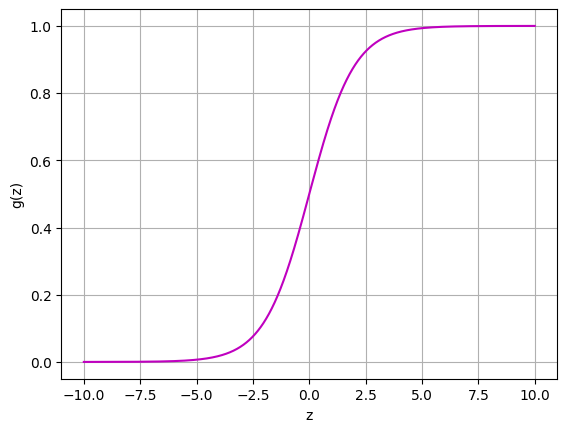

In [2]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

z = np.arange(-10,10,0.001)
gz = sigmoid(z)
plt.plot(z,gz,'m-')
plt.xlabel('z')
plt.ylabel('g(z)')
plt.grid()
plt.show()

The classifier predicts 
$$
\begin{align*}
g(\theta^Tx) \ge 0.5 \rightarrow 1 &\;\; ,\theta^Tx \ge 0 \\
g(\theta^Tx) \lt 0.5 \rightarrow 0 &\;\; ,\theta^Tx \lt 0 \tag{4.2}
\end{align*}
$$

This means that for accurate prediction, we want (or hope) 
$$
\begin{align*}
\text{if} \;\; y^{(i)} &= 1 \rightarrow \theta^Tx \gg 0 \\
\text{if} \;\; y^{(i)} &= 0 \rightarrow \theta^Tx \ll 0  \tag{4.3}
\end{align*}
$$

So the functional margin captures the idea of yeilding (4.3). This is related to the geometric margin,  that we'll define later, that measures how close the nearest training examples to the decision boundary. In figure 4.1, the boundary line on the right subplot has largest geometric margin compared to all other lines on the left.

**Notation change** 

To simplify the math, we will define labels $y \in \{-1,+1\}$ instead of $y \in \{0, 1\}$. Hence,
$$
g(z) = 
\begin{cases}
1, \;\; z \ge 0 \\
-1, \;\; \text{otherwise} \tag{4.4}
\end{cases}
$$
Also, we will use $b$ in place of intercept term $\theta_0$ and $w_i$ for $\theta_i, \;i = 1,\ldots,d$; i.e., the logistic regression hypothesis $h_\theta(x) = g(\theta^Tx)$ becomes
$$
h_{w,b}(x) = g(w^Tx + b) \tag{4.5}
$$

For one training example, **the functional margin** of hyperplane defined by $(w,b)$  w.r.t $(x^{(i)},y^{(i)})$ is
$$
\hat{\gamma}^{(i)} = y^{(i)}(w^Tx^{(i)}+b) \tag{4.6}
$$

When compared to (4.3), with change of notation to $y \in \{-1,+1\}$, what we hope for is 
$$
\begin{align*}
\text{if} \;\; y^{(i)} &= 1 \rightarrow w^Tx^{(i)}+b \gg 0 \\
\text{if} \;\; y^{(i)} &= -1 \rightarrow w^Tx^{(i)}+b \ll 0  \tag{4.7}
\end{align*}
$$
We can combine the two statements in (4.7), together with (4.6). In order to have a confident prediction, we hope that
$$
\hat{\gamma}^{(i)} \gg 0 \tag{4.8}
$$
In fact, if $\hat{\gamma}^{(i)} \gt 0$, that means $h(x^{i}) = y^{(i)}$, the prediction is correct.

Functional margin w.r.t the whole training set is defined as the worst-case margin
$$
\hat{\gamma} = \underset{i}{min} \; \hat{\gamma}^{(i)}, \;\;\; i = 1,\ldots, n \tag{4.9}
$$

Remember that for now we assume the training set is linearly separable. We'll relax that later.

One thing about the definition of functional margin is that it is really easy to cheat and increase the functional margin. From (4.6), if you take $w$ and multiply it by any number, and take $b$ and multiply by that same number. This does not actually change the decision boundary. So you could normalize the length of your parameters. For example, hypothetically you could impose a constraint $\lVert w \rVert = 1$, or another way to do that is to take $w$ and $b$ and replace it with
$$
(w,b) \rightarrow \left(\frac{w}{\lVert w \rVert},\frac{b}{\lVert w \rVert}\right) \tag{4.10}
$$
This does not change the classification. It just rescales the parameters. This prevents cheating on the functional margin. In fact, more generally you could scale $w$ and $b$ by any value without affecting the classification. We'll come back and use this property later. 

So let's define **the geometric margin** and see how it is related to the functional margin.  First define the geometric margin w.r.t a single example. In Figure 4.2, suppose we have a linear classifier with decision line $w^Tx + b = 0$. In the upper right plane, we have $w^Tx + b \gt 0$ (classifier predicts $y = 1$) and the lower left plane corresponds to $w^Tx + b \lt 0$ (classifier predicts $y = -1$).

<img src="https://raw.githubusercontent.com/dewdotninja/mlpi/refs/heads/main/figures/geometric_margins.png" width=700 />

Figure 4.2 Geometric margin

Let's say we have one training example $(x^{(i)}, y^{(i)})$ in the upper right plane, indicated by the red circle in Figure 4.2.
Assume this is a positive example. Since it is in the plane $w^Tx + b \gt 0$, the classifier predicts this correctly. So we define the geometric margin to be the distance from the decision line to this training example, indicated by the red arrow in Figure 4.2. 

Therefore, the geometric margin of hyperplane defined by $(w,b)$ w.r.t one example $(x^{(i)}, y^{(i)})$ is described by 
$$
\gamma^{(i)} = \frac{(w^Tx^{(i)}+b)}{\lVert w \rVert} \tag{4.11}
$$
This is how the Euclidean distance from the decision line to example $i$ is computed. See [2] for the proof. 

More generally, the term $y^{(i)}$ is added to (4.11) to become
$$
\gamma^{(i)} = \frac{y^{(i)}(w^Tx^{(i)}+b)}{\lVert w \rVert} \tag{4.12}
$$
so that the defintion (4.12) applies to both positive and negative examples. So the relationship between the geometric and functional margins is 
$$
\gamma^{(i)} = \frac{\hat{\gamma}^{(i)}}{\lVert w \rVert} \tag{4.13}
$$
Finally, the geometric margin w.r.t the whole training set is the worst-case value
$$
\gamma = \underset{i}{min} \; \gamma^{(i)}, \;\;\; i = 1,\ldots, n \tag{4.14}
$$

So, the objective of optimal margin classifier is to choose the parameters $w$ and $b$ to maximize the geometric margin $\gamma$. For now we can think of the optimal margin classifier as a baby SVM; i.e., an SVM for linearly separable data. It will choose the straight line (or linear hyperplane) that maximizes $\gamma$. 

One way to pose this problem is 
$$
\begin{align*}
&\underset{\gamma,w,b}{max} \;\; \gamma \\
& s.t. \;\; \frac{y^{(i)}(w^Tx^{(i)}+b)}{\lVert w \rVert} \ge \gamma \;\; i = 1, \ldots, n \tag{4.15}
\end{align*}
$$
That is, maximize $\gamma$ subject to that every training example must have geometric margin greater than or equal to $\gamma$. However, it turns out that this is not a convex optimization problem, so it could be problematic to solve (having local optima and so on). By rewriting a few steps, we can reformulate this problem to a convex optimization problem, that can be solved easily with good numerical optimization packages. 

Recall that from (4.6), the functional margin can be scaled by any number and the decision boundary stays the same (see [CS229 video](https://youtu.be/8NYoQiRANpg?si=bDDO35cDlZk9SMaA&t=406) for an illustration ). So we can scale $\lVert w \rVert$ in (4.15) arbitrarily. The trick to simplify (4.15) is then to scale
$$
\lVert w \rVert = \frac{1}{\gamma} \tag{4.16}
$$
such that (4.15) becomes
$$
\begin{align*}
&\underset{\gamma,w,b}{max} \;\; \frac{1}{\lVert w \rVert}\\
& s.t. \;\; y^{(i)}(w^Tx^{(i)}+b)\gamma \ge \gamma \;\; i = 1, \ldots, n \tag{4.17}
\end{align*}
$$
By canceling out the $\gamma$'s in the constraint, and noting that $max \;\frac{1}{\lVert w \rVert} \rightarrow min \; \lVert w \rVert  \rightarrow min \; \frac{1}{2}\lVert w \rVert ^2$, we get a new optimization problem
$$
\begin{align*}
&\underset{w,b}{min} \;\; \frac{1}{2}\lVert w \rVert ^2\\
& s.t. \;\; y^{(i)}(w^Tx^{(i)}+b) \ge 1 \;\; i = 1, \ldots, n \tag{4.18}
\end{align*}
$$
which a convex quadratic objective and linear constraints. This optimization can be solved using commercial quadratic programming (QP) code.

Now, in order to derive the SVM, we 're gonna make an additional restriction that the parameters $w$ can be expressed as a linear combination of the training examples.
$$
w = \sum_{i=1}^M \alpha_ix^{(i)} \tag{4.19}
$$
It turns out that when the dimension of $x$ is very large, or even infinite, doing this will let us derive algorithms that work. There is a theorem called  [the representer theorem](https://en.wikipedia.org/wiki/Representer_theorem) that shows you can make this assumption without losing any performance. The proof is quite complicated, involving primal/dual optimization, and is written in [2]. Here we just give a flavor why this is a reasonable assumption. 

To make the math comes out easier later on, we actually do this.
$$
w = \sum_{i=1}^M y^{(i)}\alpha_ix^{(i)} \tag{4.20}
$$
This should cause no technical problem since ${y^{(i)}}$ is just $\{+1,-1\}$.It still says that $w$ can be represented as a linear combination of the training examples. 

The representer theorem proves that (4.20) is true at the optimal value of $w$. Let's convey why this is the case by some intuitions.

1. Referring to logistic regression, suppose that we run logistic regression with stochastic gradient descent (SGD) by initilizing the parameters $\theta = 0$ at first. Then for each iteration of SGD, $\theta$ is updated by 
$\theta := \theta - \alpha (h_\theta(x^{(i)})-y^{(i)})x^{(i)}$. (Here $\alpha$ is just learning rate and has nothing to do with $\alpha$ in (4.20)). So at each iteration we update $\theta$ by adding/subtacting some constant times some training example. So by proof of induction, if $\theta$ starts at 0, and on every itertion of SGD we're adding/subtracting a multiple of some training example, then no matter how many iterations you sun SGD, $\theta$ is still a linear combination of  your training examples. Even though we use $\theta$ in this logistic regression example, the argument is valid for $w$.  It is also valid for batch GD, when the update rule is  $\theta := \theta - \alpha \sum_{i=1}^n (h_\theta(x^{(i)})-y^{(i)})x^{(i)}$.  You can derive gradient descent for the SVM algorithm as well, and have a proof by induction that no matther how many iterations of SGD/GD, the weights will always be linear combination of the training examples.

2. Refer to Figure 4.3 below. In the left 2D subplot, let's say the classifier uses this $g(w^Tx + b) = g([2, \;\; 1]x - 2)$, with the decision boundary shown as the green line. It turns out that $w = [2, \;\; 1]^T$ is always perpendicular to the decision boundary. Now, suppose we have two examples $x^{(1)}$ and $x^{(2)}$ as shown. The linear algebra way of saying this is that the vector $w$ lies in the span of the training example. The way to picture this is $w$ sets the direction of the decision boundary, and as we vary $b$, it will move the decision boundary in the  $w$ direction.  For the right 3D subplot, for the sake of illustration let's say that all examples lie in the X1-X2 plane; i.e., $x_3 = 0$. Then the decision boundary will be a vertical plane as shown, satisfying $w^Tx+b = 0$. The vector $w$ should have $w_3 = 0$; i.e., $w$ should be represented as the span of just the features $x_1$ and $x_2$.  

<img src="https://raw.githubusercontent.com/dewdotninja/mlpi/refs/heads/main/figures/intuition2.png" width=700 />

Figure 4.3 Illustration of intuition 2 for (4.20)

So, from (4.20) and using $\lVert w \rVert ^2 = w^Tw$, the objective of our optimization problem (4.18) becomes 
$$
\begin{align*}
&\underset{\alpha}{min} \;\; \frac{1}{2}\left( \sum_{i=1}^{n}\alpha_iy^{(i)}x^{(i)}\right)^T\left( \sum_{j=1}^{n}\alpha_jy^{(j)}x^{(j)}\right) \\
=& \;\underset{\alpha}{min} \;\; \frac{1}{2} \sum_{i=1}^{n} \sum_{j=1}^{n} \alpha_i \alpha_j y^{(i)}y^{(j)}{x^{(i)}}^T x^{(j)} \\
=& \;\underset{\alpha}{min} \;\; \frac{1}{2} \sum_{i=1}^{n} \sum_{j=1}^{n} \alpha_i\alpha_jy^{(i)}y^{(j)}\langle x^{(i)}, x^{(j)}\rangle \tag{4.21}
\end{align*}
$$

Here we use $\langle x,z\rangle$ to denote the inner product $x^Tz$ between two vectors. Expressing an algorithm in terms of inner products between features is the key mathematical step needed to derive kernels.

And the constraints in (4.18) becomes

$$
\begin{align*}
&y^{(i)}\left(\left(\sum_j \alpha_j y^{(j)}x^{(j)}\right)^Tx^{(i)}+b\right) \ge 1   \\
\Rightarrow \; &y^{(i)}\left(\sum_j \alpha_j y^{(j)}\langle x^{(j)}x^{(i)}\rangle +b\right) \ge 1  \tag{4.22}
\end{align*}
$$

And the key property we will use s that, if you look at (4.21), (4.22) in terms of how we pose the optimization problem, the only place that this feature vectors appears is in this inner product $\langle x^{(i)}x^{(j)}\rangle$. It turns out when we talk about "the kernel trick" with the application of kernels, if we can compute this inner product very efficiently, we can get away with manipulating even infinite dimensional feature vectors. We will see exactly how to do that. 

We now can simplify this optimization problem further to this
$$
\begin{align*}
&\underset{\alpha}{max} \; \sum_i \alpha_i - \frac{1}{2}\sum_i \sum_j y^{(i)}y^{(j)}\alpha_i \alpha_j\langle x^{(i)}x^{(j)}\rangle \\ 
s.t. \; &\alpha_i \ge 0, \;\; i = 1, \ldots, n \\
&\sum_i \alpha_i y^{(i)} = 0  \tag{4.23}
\end{align*}
$$

The derivation of this **dual optimization** is relatively complicated, involving complex optimization theory, and is provided in [2]. 

To make a prediction, 

1) Solve for $\alpha_i$ and $b$ 
2) Compute $h_{w,b}(x)$ for new test example
$$
\begin{align*}
h_{w,b}(x) &= g(w^Tx + b) \\
&= g\left(\left(\sum_i \alpha_i y^{(i)}x^{(i)}\right)^Tx + b\right) \\
&= g\left(\sum_i \alpha_iy^{(i)}\langle x^{(i)},x \rangle + b\right) 
\end{align*}
$$
Note that once $\alpha_i, b$ are stored in memory, we can make predictions using just inner products.

So we are now ready to apply kernels (often called "kernel tricks" by ML people). The recipe is as follows:

1) Write your whole algorithm in terms of $\langle x^{(i)},x^{(j)} \rangle$. Or in general, we write it as $\langle x,z \rangle$ for inner product of two vectors $x,z$.

2) Let there be some mapping $x \rightarrow \phi(x)$ from low dimensional feature space $x$ to higher dimensional $\phi(x)$. See some examples from ["Lecture 7 of CS229 video"](https://youtu.be/8NYoQiRANpg?si=1NLps11cdmFiL0sp&t=1798).

3) Find a way to compute **the kernel function** $K(x,z)=\phi(x)^T\phi(z)$. We'll see that there are clever tricks to compute the inner product between $x$ and $z$ even when $\phi(x),\phi(z)$ are incredibly high dimensional. 

4) Replace $\langle x,z \rangle$ in algorithm with $K(x,z)$.  In essence, we 're running the whole learning algorithm on this high dimensional set of features. It can be very computationally expensive working with high dimensional feature vectors $\phi(x)$. But instead we don't have to compute it explicitly. We can always just compute the kernel $K(x,z)$ 

**Example**

**Note :** See ["Lecture 7 of CS229 video"](https://youtu.be/8NYoQiRANpg?si=-N2l8vGLtq3RgUgG&t=2075) for details of this example on kernels. Here we just outline it. 

Let the feature be 3 dimensional 
$$
x = \left[\begin{array}{c}
x_1 \\
x_2 \\
x_3
\end{array}\right]
$$
Choose feature mapping $\phi(x)$ to be all pair-wise of monimial terms
$$
\phi(x) = \left[\begin{array}{c}
x_1x_1 \\
x_1x_2 \\
x_1x_3 \\
x_2x_1 \\
x_2x_2 \\
x_3x_1 \\
x_3x_2 \\
x_3x_3
\end{array}\right]
$$
There are a couple of duplicates but we'll just write it out this way. For this monomial mappling, if $x \in \mathbb{R}^n$, then $\phi(x) \in \mathbb{R}^{n^2}$. Here we choose small number $n=3$ for illustration purpose. In practice, think of $x$ as, say, 1000 dimensional and the mapping is now a million. 

So $\phi(z)$
 becomes
$$
\phi(z) = \left[\begin{array}{c}
z_1z_1 \\
z_1z_2 \\
\vdots \\
z_3z_3
\end{array}\right]
$$
We have gone from $n$ to $n^2$ features, so $\phi(z)$ has $n^2$ elements. We need $O(n^2)$ time to compute $\phi(z)$ or $\phi(x)^T\phi(z)$ explicity.

Let's see if we can find a better way to do that. What we want is to write out the kernel of $x,z$; i.e., 
$$
K(x,z) = \phi(x)^T\phi(z) \tag{4.24}
$$.

 What we'll show is that (4.24) can be computed as
$$
K(x,z) = (x^Tz)^2 \tag{4.25}
$$

The cool thing is that, since $x$ and $z$ are n-dimensional, so (4.25) is just $O(n)$ time computation, instead of $O(n^2)$ for computing (4.24) 

To show (4.25) is equavalent to (4.24), we expand and rearrange terms 
$$
\begin{align*}
K(x,z) &= \left(\sum_{i=1}^n x_iz_i\right)\left(\sum_{j=1}^n x_jz_j\right) \\
&= \sum_{i=1}^n \sum_{j=1}^n x_iz_ix_jz_j \\
&= \sum_{i=1}^n \sum_{j=1}^n(x_ix_j)(z_iz_j) \tag{4.26}
\end{align*}
$$

Note that the last line of (4.25) is the process of computing (4.24) explicitly. 

Some other examples of kernels. Let's consider
$$
K(x,z) = (x^Tz + c)^2 \tag{4.27}
$$
where we add a constant $c$ to $x^Tz$ before squaring it. That corresponds to modifying  your features as follows. 
Instead of computing just binomial terms as before, we add elements of $x_1, x_2, x_3$  with some weightings $\sqrt{2c}$, and lastly the constant $c$ to the vector.
$$
\phi(x) = \left[\begin{array}{c}
x_1x_1 \\
x_1x_2 \\
x_1x_3 \\
x_2x_1 \\
x_2x_2 \\
x_3x_1 \\
x_3x_2 \\
x_3x_3 \\
\sqrt{2c}\;x_1 \\
\sqrt{2c}\;x_2 \\
\sqrt{2c}\;x_3 \\
c
\end{array}\right] \tag{4.28}
$$
That is, the role of constant $c$ is to trade off the relative weighting between the binomial terms compared to the first-degree terms $x_1, x_2, x_3$.

Another example is, if you raise (4.28) to the power of $d$ instead of $2$
$$
K(x,z) = (x^Tz+c)^d \tag{4.29}
$$
Notice that this is still $O(n)$ time computation, because the term in parenthesis is just a number. But this corresponds to $\phi(x)$ with $\left(\begin{array}{c}n+d \\d\end{array}\right)$ terms, containing all monomial feature terms up to order $d$. For example, if $d = 5$, this contains all fifth-order monomial features of the form $x_ix_jx_kx_lx_m$, which is a very large number of features, but your computation doesn't blow up exponentially even as $d$ increases.  

So, an SVM takes the optimal margin classifier that we derived earlier, and applies the kernel trick to it. So if we choose some of these kernels as in the examples, then we could run an SVM in these very high-dimensional feature spaces, say 100 trillions dimension, but your computational time scales only linearly as order $n$.

<img src="https://raw.githubusercontent.com/dewdotninja/mlpi/refs/heads/main/figures/svm_structure.png" width=600 />

Why is this a good idea? In his lecture, Andrew cited [this video from Youtube](https://youtu.be/8NYoQiRANpg?si=OK1qVsspY7vZffcj&t=2830) to demonstrate the use of kernels in SVM. The original video is provided below. 

["SVM with a polynomial kernel visualization"](https://youtu.be/OdlNM96sHio?si=2H-ACkviWeeniJC4) by udiprod.com. This short video demonstrates how vectors of two classes that cannot be linearly separated in 2-D space, can become linearly separated by a transformation function into a higher
dimensional space.

By applying kernels to SVM, we could learn very nonlinear decision boundary such as the one shown in Figure 4.4. It is actually a linear decision boundary in a very high-dimensional space, then projects back down in 2D.  
 
<img src="https://raw.githubusercontent.com/dewdotninja/mlpi/refs/heads/main/figures/svm_nonlinear_boundary.png" width=650 />

Figure 4.4 learning a nonlinear boundary with SVM

#### How to make kernels? 

Here is some intuition you might have about kernels. If $x$ and $z$ are similar, or close to each other, then $K(x,z) = \phi(x)^T\phi(z)$, which is related to the inner product between $x$ and $z$,  should be "large." Conversely, if $x$ and $z$ are dissimilar, then $K(x,z)$ should be "small." As an example, let's define **the Gaussian kernel**
$$
K(x,z) = exp\left(-\frac{\lVert x-z\rVert ^2}{2\sigma^2}\right) \tag{4.30}
$$
This function has the property of similarity; i.e., if $x$ and $z$ are close together $K(x,z) \rightarrow 1$, while if they 're apart, $K(x,z) \rightarrow 0$. So it satisfies the criteria. Is it OK to use this as a kernel function? 

It turns out that it can be used, only if there exists some $\phi$ such that $K(x,z) = \phi(x)^T\phi(z)$. So we derived the whole algorithm assuming this to be true, and it turns out if we plug in the kernel function for which this is not true, then all of the derivation we wrote down breaks down and the optimization problem can have very strange solutions.That doesn't correspond to having a good classification at all. 

This put some constraints on what kernel functions we could choose. For example, one thing it must satisfy is the definition of inner product
$$
K(x,x) = \phi(x)^T\phi(x) \ge 0 \tag{4.31}
$$

More generally, there is a theorem that proves whether some choice is a valid kernel. Here we briefly outline that proof. 

Let $\{x^{(1)},\ldots,x^{(d)}\}$ be any $d$ points, and 
$$
\mathbf{K} \in \mathbb{R}^{d \times d} \tag{4.32}
$$
represent **a kernel matrix** (sometimes called a gram matrix), so that $\mathbf{K}_{ij} = K(x^{(i)},x^{(j)})$. 

Given any vector $z$, 
$$
\begin{align*}
z^T\mathbf{K}z &= \sum_i \sum_j z_i \mathbf{K}_{ij}z_j  \\
&= \sum_i \sum_j z_i \phi(x^{(i)})^T\phi(x^{(j)} z_j \\
&= \sum_i \sum_j z_i \sum_k (\phi(x^{(i)}))_k(\phi(x^{(j)})_k z_j \\
&= \sum_k \sum_i \sum_j z_i (\phi(x^{(i)}))_k(\phi(x^{(j)})_k z_j \\
&= \sum_k \left(\sum_i  z_i (\phi(x^{(i)}))_k\right)^2 \\
&\ge 0 \tag{4.33}
\end{align*}
$$

So this proves that $\mathbf{K} \ge 0$; i.e., the matrix $\mathbf{K}$ is positive semidefinite.

It turns out that this is also a sufficient condition for our function $K$ to be a valid kernel function. This is called [Mercer's Theorem](https://en.wikipedia.org/wiki/Mercer%27s_theorem).  

$K$ is a valid kernel function (i.e., $\exists \; K(x,z) = \phi(x)^T\phi(z)$) if and only if for any $d$ points $\{x^{(1)},\ldots,x^{(d)}\}$, the corresponding kernel matrix $\mathbf{K} \ge 0$.  

We have shown just one direction of this implication.

It turns out that the Gaussian kernel (4.30) is a valid kernel.

Perhaps the most widely used kernel is the **linear kernel** that has no high dimensional features
$$
\begin{align*}
K(x,z) &= x^Tz \\
\phi(x) &= x  \tag{4.34}
\end{align*}
$$
;i.e., the feature mapping is just equal to the original features. 

Second to that is probably the Gaussion kernel (4.30), that corresponds to an infinite dimensional feature space; $\phi(x) \in \mathbb{R}^\infty$. Actually, this particular kernel function corresponds to using all monomial features, say $x_1,\; x_1x_2,\; x_1^2x_2,\; x_1^2x_2^{10}\;,\ldots \;,x1^{10000}x_2^{1701}\;, \ldots$, giving smaller weightings to the very high dimensional ones. 

The kernel trick  was popularized by SVM where researchers Vladimir Vapnik and Corinna Cortes [4] found that applying these kernel tricks to an SVM results in a very effective learning algorithm. But the kernel trick is indeed more general than SVM. Any learning algorithm that we can write in terms of inner products $\langle x^{(i)},x^{(j)} \rangle$, then we can apply the kernel trick to it. All of the discriminative algorithms we 've learnt so far, such as linear and logistic regression, perceptron, can be written this way so that you can apply the kernel trick. Though in practice, it is used all the time in SVM and less often in other algorithms. 

Last two things for this SVM materials, one is to fix the assumption that we had made the data linearly separable. Sometimes we don't want our learning algorithm to have zero errors on the training set. When we take low dimensinal data and map it to a very high dimensional feature space, the data does become much more separable. But if your dataset is a little bit noisy, such as in Figure 4.4, we may not want to try so hard to separate every little example to define a complicated decision boundary. 

#### 4.1.2 Soft margin SVM

From the basic SVM algorityhm (4.18), repeated below for convenience
$$
\begin{align*}
&\underset{w,b}{min} \;\; \frac{1}{2}\lVert w \rVert ^2\\
& s.t. \;\; y^{(i)}(w^Tx^{(i)}+b) \ge 1 \;\;, \; i = 1, \ldots, n,
\end{align*}
$$
there is an algorithm called the $L_1$ norm soft margin SVM, which is a modification of the basic algorithm
$$
\begin{align*}
&\underset{w,b,\xi_i}{min} \;\; \frac{1}{2}\lVert w \rVert ^2 + C \sum_{i=1}^n\xi_i \\
& s.t. \;\; y^{(i)}(w^Tx^{(i)}+b) \ge 1 -\xi_i \;\;, \;  i = 1, \ldots, n, \;\; \\
& \;\;\;\;\;\;\; \xi_i \ge 0 
\end{align*} \tag{4.35}
$$
by relaxing the constraint on lower bound of the functional margin from $1$, to $1 - \xi_i$,  where $\xi_i \ge 0$ and then modify the cost function to penalize $\xi_i$

Remember that, in the basic SVM, if the functional margin is greater than or equal to $0$, it means the algorithm is classifying that example correctly; i.e., $y^{(i)}$ and $(w^Tx^{(i)}+b)$ have the same sign, either ++ or --. Not only that, the SVM poses stronger requirement that it must classify correctly with the functional margin be at least 1. 

Now, in the soft margin SVM, if we allow $\xi_i \ge 0$, then that constraint is relaxed. But we do not want $\xi_i$ to be too large, so we add a penalty term on $\xi_i$ to the cost function.

We can consider $C$ as a hyperparameter for controlling the penalty for misclassification.
Large values of $C$ correspond to large error penalties, whereas we are less strict about misclassification
errors if we choose smaller values for $C$. We can then use the $C$ parameter to control the width of the
margin and therefore tune the bias-variance tradeoff, as illustrated in Figure 4.5 (from Figure 3.11 of [1])

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch03/figures/03_10.png" width=800 />

Figure 4.5 Impact of $C$ on regularization [1]

See the rest of this discussion and picture illustration from [CS229 video](https://youtu.be/8NYoQiRANpg?si=xD6mfly6_ZqRTuRq&t=4078)

The last topic for SVM is just a list of widely-used SVM kernels. First the SVM with polynomial kernel
$$
K(x,z) = (x^Tz)^d \tag{4.36}
$$
that works quite well. Next, the Gaussian kernel (4.30), repeated below
$$
K(x,z) = exp\left(-\frac{\lVert x-z\rVert ^2}{2\sigma^2}\right) 
$$
which is also called **radial basis function (RBF)**


Some time ago before the CNN, SVM was doing a great job on image classification.

[Protein sequence classifier example on CS229 video](https://youtu.be/8NYoQiRANpg?si=VGF4cGBsUTYyUNpj&t=4527)

**Note :** Some of the materials above are also covered in Chapter 3 of [1] (p.76 - 86)

#### 4.1.3 SVM in practice

Now we want to train some SVM, using code from [1] (p. 78). 

##### Iris dataset example

First we use it to classify the Iris dataset.

In [3]:
from sklearn import datasets
import numpy as np

iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

print('Class labels:', np.unique(y))

Class labels: [0 1 2]


Splitting data into 70% training and 30% testing

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)

print('Labels counts in y:', np.bincount(y))
print('Labels counts in y_train:', np.bincount(y_train))
print('Labels counts in y_test:', np.bincount(y_test))

Labels counts in y: [50 50 50]
Labels counts in y_train: [35 35 35]
Labels counts in y_test: [15 15 15]


Standardizing the features

In [5]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

In [6]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

# To check recent matplotlib compatibility
import matplotlib
from distutils.version import LooseVersion

X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))

def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):

    # setup marker generator and color map
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=f'Class {cl}', 
                    edgecolor='black')

    # highlight test examples
    if test_idx:
        # plot all examples
        X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(X_test[:, 0],
                    X_test[:, 1],
                    c='none',
                    edgecolor='black',
                    alpha=1.0,
                    linewidth=1,
                    marker='o',
                    s=100, 
                    label='Test set')        

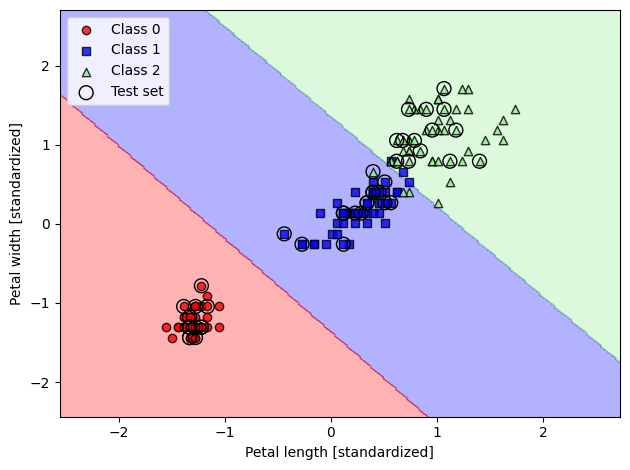

In [7]:
from sklearn.svm import SVC

svm = SVC(kernel='linear', C=1.0, random_state=1)
svm.fit(X_train_std, y_train)

plot_decision_regions(X_combined_std, 
                      y_combined,
                      classifier=svm, 
                      test_idx=range(105, 150))
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

##### Solving nonlinear problem with SVM

Create a simple XOR dataset using logical_xor function from numpy, where each class label 1 and -1 have 100 examples.

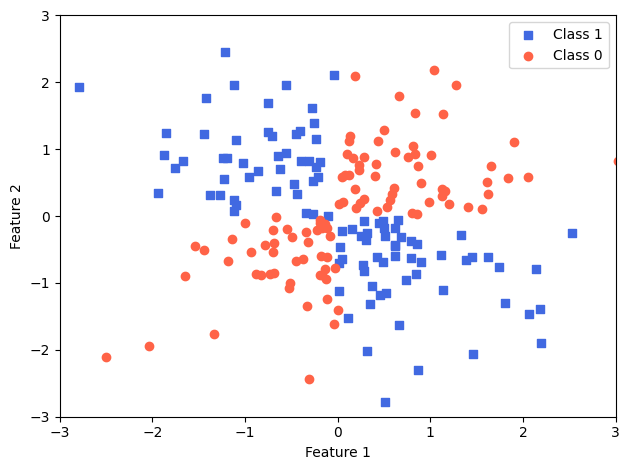

In [8]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(1)
X_xor = np.random.randn(200, 2)
y_xor = np.logical_xor(X_xor[:, 0] > 0,
                       X_xor[:, 1] > 0)
y_xor = np.where(y_xor, 1, 0)

plt.scatter(X_xor[y_xor == 1, 0],
            X_xor[y_xor == 1, 1],
            c='royalblue',
            marker='s',
            label='Class 1')
plt.scatter(X_xor[y_xor == 0, 0],
            X_xor[y_xor == 0, 1],
            c='tomato',
            marker='o',
            label='Class 0')

plt.xlim([-3, 3])
plt.ylim([-3, 3])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.legend(loc='best')
plt.tight_layout()
plt.show()

Use the kernel trick to find separating hyperplanes in higher dimensional space.

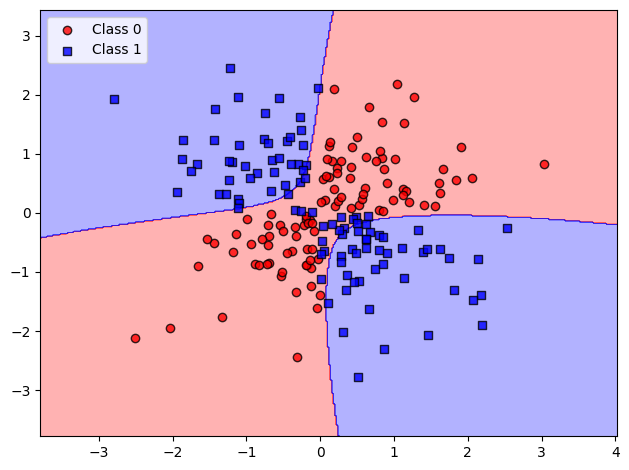

In [9]:
svm = SVC(kernel='rbf', random_state=1, gamma=0.10, C=10.0)
svm.fit(X_xor, y_xor)
plot_decision_regions(X_xor, y_xor,
                      classifier=svm)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

Results from applying kernel SVM to Iris dataset. Note that in the RBF (Gaussian) kernel
$$
K(x,z) = exp\left(-\frac{\lVert x-z\rVert ^2}{2\sigma^2}\right) 
$$
is often simplified to
$$
K(x,z) = exp (-\gamma \lVert x-z\rVert ^2) 
$$
Here, $\gamma = \frac{1}{2\sigma^2}$ corresponds to a hyperparameter used in scikit-learn. It has nothing to do with $\gamma$ used in functional and geometric margins in Section 4.1.1.

The $\gamma$ parameter, which we set to gamma=0.1, can be understood as a cut-off parameter for the Gaussiansphere. If we increase the value for $\gamma$ , we increase the influence or reach of the training examples,
which leads to a tighter and bumpier decision boundary. To get a better understanding of $\gamma$ , let’s apply
an RBF kernel SVM to our Iris flower dataset:

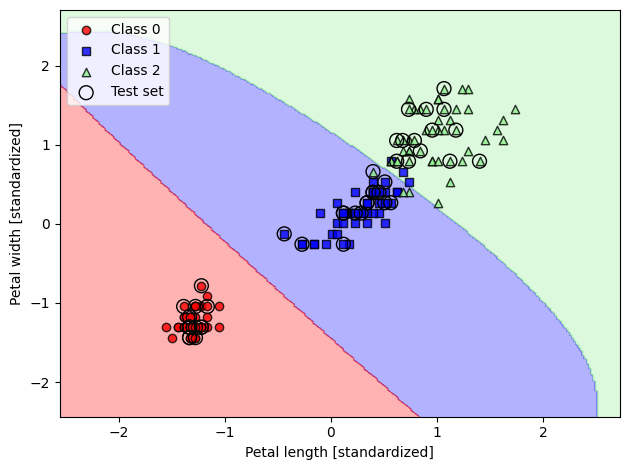

In [10]:
from sklearn.svm import SVC
svm = SVC(kernel='rbf', random_state=1, gamma=0.2, C=1.0)
svm.fit(X_train_std, y_train)

plot_decision_regions(X_combined_std, y_combined,
                      classifier=svm, test_idx=range(105, 150))
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

Since we chose a relatively small value for $\gamma$ , the resulting decision boundary of the RBF kernel SVM model will be relatively soft. Now, let's increase hte value of $\gamma$ and observe the effect on the decision boundary.

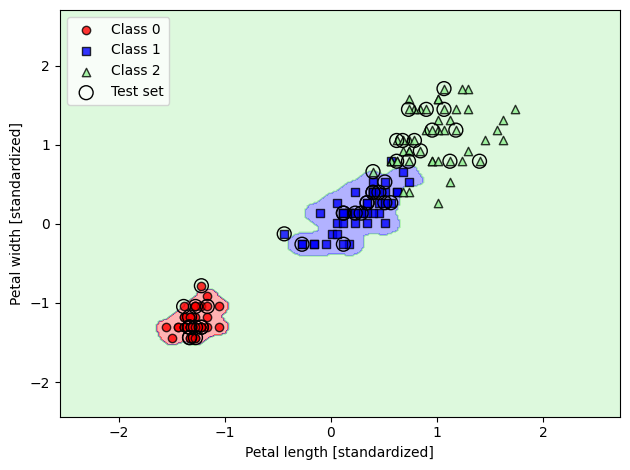

In [11]:
svm = SVC(kernel='rbf', random_state=1, gamma=100.0, C=1.0)
svm.fit(X_train_std, y_train)
plot_decision_regions(X_combined_std, y_combined, 
                      classifier=svm, test_idx=range(105, 150))
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

We can now see that the decision boundary around the classes 0 and 1 is much tighter
using a relatively large value of $\gamma$. Although the model fits the training dataset very well, such a classifier will likely have a high generalization
error on unseen data. This illustrates that the $\gamma$ parameter also plays an important role in controlling
overfitting or variance when the algorithm is too sensitive to fluctuations in the training dataset.


## 4.2 K-nearest neighbor algorithm

From Wikipedia : https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm 

"In statistics, the k-nearest neighbors algorithm (k-NN) is a non-parametric supervised learning method. It was first developed by Evelyn Fix and Joseph Hodges in 1951,[5] and later expanded by Thomas Cover.[6] Most often, it is used for classification, as a k-NN classifier, the output of which is a class membership. An object is classified by a plurality vote of its neighbors, with the object being assigned to the class most common among its k nearest neighbors (k is a positive integer, typically small). If k = 1, then the object is simply assigned to the class of that single nearest neighbor."

Related videos : [Intro to Machine Learning by Sebastian Raschka](https://youtube.com/playlist?list=PLTKMiZHVd_2KyGirGEvKlniaWeLOHhUF3&si=2dwNEAm5CRChplqM) Lecture 2.1 - 2.6

The following discussion and code are from [1]

The KNN algorithm itself is fairly straightforward and can be summarized by the following steps:

1. Choose the number of k and a distance metric
2. Find the k-nearest neighbors of the data record that we want to classify
3. Assign the class label by majority vote

Figure 4.6 (from [1] Figure 3.25) illustrates how a new data point (?) is assigned the triangle class label based on majority
voting among its five nearest neighbors.

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch03/figures/03_23.png" width=700 />

Figure 4.6 How k-nearest neighbors works

See [1] (p 101) on the choices of distance metric.

Based on the chosen distance metric, the KNN algorithm finds the k examples in the training dataset
that are closest (most similar) to the point that we want to classify. The class label of the data point is
then determined by a majority vote among its k nearest neighbors.

By specifying five neighbors in the KNN model for this dataset, we obtain a relatively smooth decision boundary.


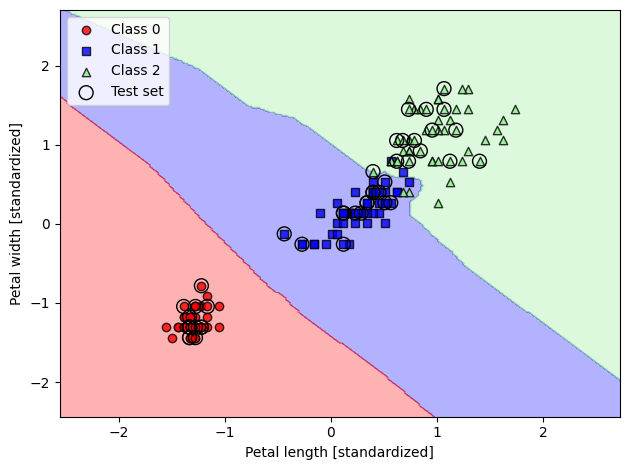

In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5, 
                           p=2, 
                           metric='minkowski')
knn.fit(X_train_std, y_train)

plot_decision_regions(X_combined_std, y_combined, 
                      classifier=knn, test_idx=range(105, 150))

plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
#plt.savefig('figures/03_24_figures.png', dpi=300)
plt.show()

### References

1. S. Raschka, Y. Liu and V. Mirjalili. [Machine Learning with PyTorch 
and Scikit-Learn.](https://sebastianraschka.com/blog/2022/ml-pytorch-book.html) Packt Publishing. 2022.  

2. A. Ng. [CS229 Lecture Notes.](https://cs229.stanford.edu/main_notes.pdf) Stanford University. 2023.[Related video](https://youtu.be/4b4MUYve_U8?si=qa3iBTO2R-abQViu) 

3. T. Broderick. [Introduction to Machine Learning course (6.036).](https://tamarabroderick.com/ml.html) Massachusetts Institute of Technology. 2020. [Related video](https://youtu.be/OpvrwhWEUmY?si=bS8VZYsrZMqvnuII)  

4. C. Cortes and V. Vapnik. "Support-vector networks". Machine Learning. 20 (3): 273–297. CiteSeerX 10.1.1.15.9362. 1995.

5. E. Fix and J.L. Hodges. Discriminatory Analysis. Nonparametric Discrimination: Consistency Properties (Report). USAF School of Aviation Medicine, Randolph Field, Texas. 1951. 

6. T.M. Cover and P.E. Hart. "Nearest neighbor pattern classification". IEEE Transactions on Information Theory. 13 (1): 21–27. 1967.


<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2025</div>